In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X = np.load('/lustre09/project/6081099/reem2005/DATASET/X_windows.npy')
y = np.load('/lustre09/project/6081099/reem2005/DATASET/y_windows.npy')
groups = np.load('/lustre09/project/6081099/reem2005/DATASET/groups.npy')

print("X shape:", X.shape)
print("Subjects:", np.unique(groups))

X shape: (28727, 100, 18)
Subjects: [101 102 103 104 105 106 107 108]


In [2]:
subject_id = 108

mask_108 = groups == subject_id
X_108 = X[mask_108]
y_108 = y[mask_108]

print(f"عدد نوافذ subject {subject_id}:", len(X_108))
print(f"\nتوزيع الفئات لـ subject {subject_id}:")
print(pd.Series(y_108).value_counts().sort_index())

print(f"\nمقارنة: متوسط عدد النوافذ لكل subject بالمجموعة كلها:")
for s in np.unique(groups):
    print(f"  subject {s}: {np.sum(groups == s)} نافذة")

عدد نوافذ subject 108: 3633

توزيع الفئات لـ subject 108:
0    482
1    457
2    502
3    629
4    231
5    190
6    484
7    658
Name: count, dtype: int64

مقارنة: متوسط عدد النوافذ لكل subject بالمجموعة كلها:
  subject 101: 3424 نافذة
  subject 102: 3704 نافذة
  subject 103: 3470 نافذة
  subject 104: 3608 نافذة
  subject 105: 3768 نافذة
  subject 106: 3581 نافذة
  subject 107: 3539 نافذة
  subject 108: 3633 نافذة


In [3]:
# Compare signal statistics across subjects to detect outliers
sensor_stats = []

for s in np.unique(groups):
    X_s = X[groups == s]
    sensor_stats.append({
        "subject": s,
        "mean_signal": X_s.mean(),
        "std_signal": X_s.std(),
        "min_signal": X_s.min(),
        "max_signal": X_s.max(),
    })

sensor_stats_df = pd.DataFrame(sensor_stats)
print(sensor_stats_df)

   subject  mean_signal  std_signal  min_signal  max_signal
0      101     0.887650    4.522860 -155.356003  104.730003
1      102     0.738234    4.628710  -98.744797  155.541000
2      103     1.032889    4.682922 -158.925995  156.190002
3      104     0.959121    4.382151  -74.452698   86.726097
4      105     0.962530    4.386340  -66.308502  112.462997
5      106     0.966149    4.384451 -146.850998  150.182999
6      107     0.756034    4.651076 -122.817001  127.370003
7      108     0.452972    4.626022 -146.195999  153.541000


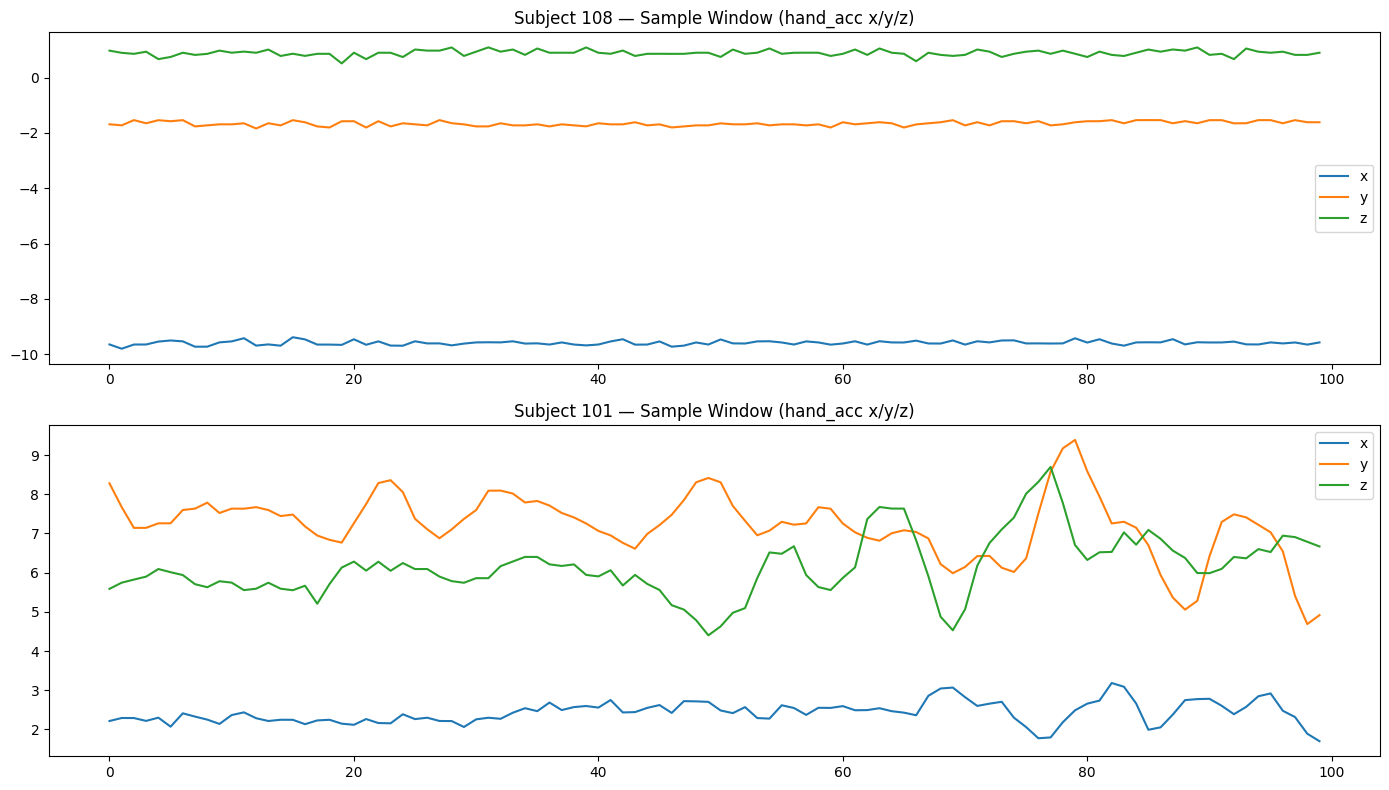

In [4]:
# Visual comparison: subject 108 vs a well-performing subject (101)
normal_subject = 101
subject_id = 108

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Subject 108 (problematic)
sample_108 = X[groups == subject_id][0]  # first window
axes[0].plot(sample_108[:, :3])  # first 3 channels (hand_acc)
axes[0].set_title(f"Subject {subject_id} — Sample Window (hand_acc x/y/z)")
axes[0].legend(["x", "y", "z"])

# Normal subject
sample_normal = X[groups == normal_subject][0]
axes[1].plot(sample_normal[:, :3])
axes[1].set_title(f"Subject {normal_subject} — Sample Window (hand_acc x/y/z)")
axes[1].legend(["x", "y", "z"])

plt.tight_layout()
plt.show()

In [5]:
# Test whether subject 108 is genuinely hard to classify,
# using a simple Random Forest (not sensitive to Mean Teacher training details)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

subject_id = 108
train_mask = groups != subject_id
test_mask = groups == subject_id

X_train_flat = X[train_mask].reshape(len(X[train_mask]), -1)
X_test_flat = X[test_mask].reshape(len(X[test_mask]), -1)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_flat, y[train_mask])
y_pred = rf.predict(X_test_flat)

print(f"Random Forest — Subject {subject_id} as held-out test:")
print(classification_report(y[test_mask], y_pred))

Random Forest — Subject 108 as held-out test:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       482
           1       0.84      0.96      0.90       457
           2       0.76      0.84      0.80       502
           3       0.97      0.64      0.78       629
           4       0.47      0.80      0.59       231
           5       0.69      0.76      0.72       190
           6       0.90      0.81      0.85       484
           7       0.89      0.87      0.88       658

    accuracy                           0.83      3633
   macro avg       0.82      0.83      0.81      3633
weighted avg       0.86      0.83      0.84      3633



In [6]:
SENSOR_COLUMNS = [
    "hand_acc16_x","hand_acc16_y","hand_acc16_z",
    "hand_gyro_x","hand_gyro_y","hand_gyro_z",
    "chest_acc16_x","chest_acc16_y","chest_acc16_z",
    "chest_gyro_x","chest_gyro_y","chest_gyro_z",
    "ankle_acc16_x","ankle_acc16_y","ankle_acc16_z",
    "ankle_gyro_x","ankle_gyro_y","ankle_gyro_z",
]

subject_id = 108
X_p108 = X[groups == subject_id]

print("Per-channel std for subject 108 (low std = flat/problematic channel):")
for i, col in enumerate(SENSOR_COLUMNS):
    std_108 = X_p108[:, :, i].std()
    std_others = X[groups != subject_id][:, :, i].std()
    flag = " ⚠️ LOW" if std_108 < std_others * 0.5 else ""
    print(f"  {col:20s} | subject108 std={std_108:.3f} | others std={std_others:.3f}{flag}")

Per-channel std for subject 108 (low std = flat/problematic channel):
  hand_acc16_x         | subject108 std=6.253 | others std=5.744
  hand_acc16_y         | subject108 std=3.557 | others std=3.290
  hand_acc16_z         | subject108 std=3.190 | others std=3.533
  hand_gyro_x          | subject108 std=1.174 | others std=1.242
  hand_gyro_y          | subject108 std=0.828 | others std=0.766
  hand_gyro_z          | subject108 std=1.223 | others std=1.294
  chest_acc16_x        | subject108 std=1.435 | others std=1.625
  chest_acc16_y        | subject108 std=4.270 | others std=3.677
  chest_acc16_z        | subject108 std=4.505 | others std=4.704
  chest_gyro_x         | subject108 std=0.276 | others std=0.298
  chest_gyro_y         | subject108 std=0.465 | others std=0.486
  chest_gyro_z         | subject108 std=0.229 | others std=0.254
  ankle_acc16_x        | subject108 std=5.716 | others std=5.222
  ankle_acc16_y        | subject108 std=6.193 | others std=6.200
  ankle_acc16_z     

In [10]:
import torch
import torch.nn as nn

class CNN1DBase(nn.Module):
    def __init__(self, input_window, input_features, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, input_features, input_window)
            flat_dim = self.conv(dummy).flatten(1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (batch, features, window)
        x = self.conv(x)
        return self.classifier(x)

CNN — Subject 108, per-activity breakdown:
              precision    recall  f1-score   support

           0       0.12      0.01      0.01       482
           1       0.12      0.14      0.13       457
           2       0.24      0.26      0.25       502
           3       0.93      0.11      0.19       629
           4       0.90      0.08      0.15       231
           5       0.12      0.81      0.21       190
           6       0.49      0.86      0.63       484
           7       0.70      0.36      0.48       658

    accuracy                           0.30      3633
   macro avg       0.45      0.33      0.26      3633
weighted avg       0.48      0.30      0.28      3633



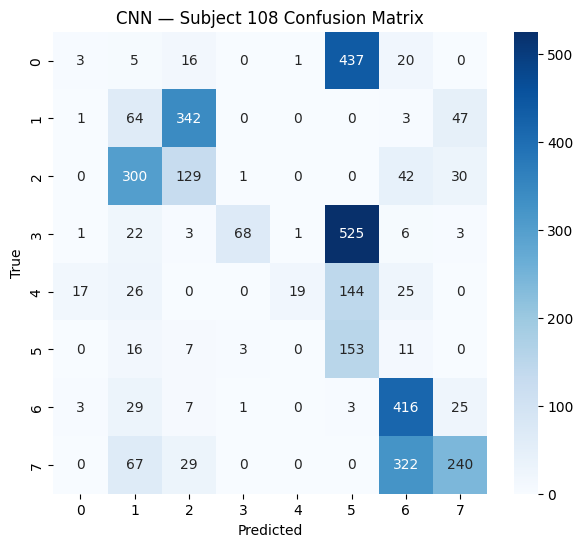

In [11]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# استخدمي الموديل المدرب أصلاً من Mean Teacher notebook (baseline_model من آخر fold)
# أو درّبي CNN بسيط سريع هون بس للفحص:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_mask = groups != subject_id
test_mask = groups == subject_id

model = CNN1DBase(X.shape[1], X.shape[2], len(np.unique(y))).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

X_train_t = torch.tensor(X[train_mask], dtype=torch.float32)
y_train_t = torch.tensor(y[train_mask], dtype=torch.long)

from torch.utils.data import TensorDataset, DataLoader
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)

model.train()
for epoch in range(15):
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = torch.nn.functional.cross_entropy(model(xb), yb)
        loss.backward()
        optimizer.step()

model.eval()
X_test_t = torch.tensor(X[test_mask], dtype=torch.float32).to(device)
with torch.no_grad():
    preds = model(X_test_t).argmax(dim=1).cpu().numpy()

print("CNN — Subject 108, per-activity breakdown:")
print(classification_report(y[test_mask], preds))

cm = confusion_matrix(y[test_mask], preds)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("CNN — Subject 108 Confusion Matrix")
plt.show()

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_flat, y[train_mask])
y_pred_knn = knn.predict(X_test_flat)

print("KNN — Subject 108:")
print(classification_report(y[test_mask], y_pred_knn))

KNN — Subject 108:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       482
           1       0.57      0.51      0.54       457
           2       0.33      0.84      0.48       502
           3       0.32      0.02      0.03       629
           4       0.13      0.10      0.11       231
           5       0.40      0.15      0.22       190
           6       0.76      0.70      0.73       484
           7       0.58      0.67      0.62       658

    accuracy                           0.54      3633
   macro avg       0.51      0.49      0.46      3633
weighted avg       0.54      0.54      0.49      3633



In [12]:
def normalize_window(window):
    """Per-window z-score normalization: removes signal offset per channel."""
    mean = window.mean(axis=0, keepdims=True)
    std = window.std(axis=0, keepdims=True) + 1e-8
    return (window - mean) / std

X_normalized = np.array([normalize_window(w) for w in X])
print("Normalization done. Shape:", X_normalized.shape)

# إعادة تدريب نفس CNN، بس على X_normalized
model_norm = CNN1DBase(X_normalized.shape[1], X_normalized.shape[2], len(np.unique(y))).to(device)
optimizer_norm = torch.optim.Adam(model_norm.parameters(), lr=1e-3)

X_train_norm_t = torch.tensor(X_normalized[train_mask], dtype=torch.float32)
y_train_t = torch.tensor(y[train_mask], dtype=torch.long)

train_loader_norm = DataLoader(TensorDataset(X_train_norm_t, y_train_t), batch_size=128, shuffle=True)

model_norm.train()
for epoch in range(15):
    for xb, yb in train_loader_norm:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_norm.zero_grad()
        loss = torch.nn.functional.cross_entropy(model_norm(xb), yb)
        loss.backward()
        optimizer_norm.step()

model_norm.eval()
X_test_norm_t = torch.tensor(X_normalized[test_mask], dtype=torch.float32).to(device)
with torch.no_grad():
    preds_norm = model_norm(X_test_norm_t).argmax(dim=1).cpu().numpy()

print("CNN + Z-score Normalization — Subject 108:")
print(classification_report(y[test_mask], preds_norm))

Normalization done. Shape: (28727, 100, 18)
CNN + Z-score Normalization — Subject 108:
              precision    recall  f1-score   support

           0       0.37      0.26      0.31       482
           1       0.35      0.82      0.50       457
           2       0.45      0.33      0.38       502
           3       0.96      0.08      0.14       629
           4       0.55      0.21      0.30       231
           5       0.23      0.75      0.35       190
           6       0.55      0.81      0.65       484
           7       0.82      0.48      0.61       658

    accuracy                           0.45      3633
   macro avg       0.54      0.47      0.41      3633
weighted avg       0.59      0.45      0.42      3633



In [14]:
# Combine z-score normalization (already have X_normalized) with class-weighted loss
class_counts = np.bincount(y[train_mask])
class_weights = torch.tensor(
    len(y[train_mask]) / (len(class_counts) * class_counts), dtype=torch.float32
).to(device)

model_v2 = CNN1DBase(X_normalized.shape[1], X_normalized.shape[2], len(np.unique(y))).to(device)
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=1e-3)

X_train_norm_t = torch.tensor(X_normalized[train_mask], dtype=torch.float32)
y_train_t = torch.tensor(y[train_mask], dtype=torch.long)

train_loader_v2 = DataLoader(TensorDataset(X_train_norm_t, y_train_t), batch_size=128, shuffle=True)

model_v2.train()
for epoch in range(15):
    for xb, yb in train_loader_v2:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_v2.zero_grad()
        loss = torch.nn.functional.cross_entropy(model_v2(xb), yb, weight=class_weights)
        loss.backward()
        optimizer_v2.step()

model_v2.eval()
X_test_norm_t = torch.tensor(X_normalized[test_mask], dtype=torch.float32).to(device)
with torch.no_grad():
    preds_v2 = model_v2(X_test_norm_t).argmax(dim=1).cpu().numpy()

print("CNN + Normalization + Class Weights — Subject 108:")
print(classification_report(y[test_mask], preds_v2))

CNN + Normalization + Class Weights — Subject 108:
              precision    recall  f1-score   support

           0       0.49      0.47      0.48       482
           1       0.40      0.63      0.49       457
           2       0.37      0.48      0.42       502
           3       0.00      0.00      0.00       629
           4       0.57      0.22      0.32       231
           5       0.17      0.71      0.27       190
           6       0.61      0.77      0.68       484
           7       0.80      0.35      0.49       658

    accuracy                           0.43      3633
   macro avg       0.43      0.45      0.39      3633
weighted avg       0.44      0.43      0.40      3633

